In [1]:
import numpy as np
import pandas as pd
import torch
import os
from torch.utils.data import DataLoader
from pathlib import Path

from ml_events_utils import MLEventsDataset, scale_target

print('numpy', np.__version__)
print('pandas', pd.__version__)
print('torch', torch.__version__)

# Turn off file validation for pydevd to avoid issues in some environments
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"


numpy 1.26.4
pandas 2.3.3
torch 2.2.2


### Load the momentum and weight data from the `.ml` files.

In [2]:


# Example usage for large files:
# file = Path("examplary_eventfiles/*.ml")
file = Path("event_files/pwgevents-*.ml")

dataset = MLEventsDataset(file,
                          labels = ["LL",],
                        #   transform=None,
                          target_transform=scale_target,  # Scale target by 1000
                          cache_events=False)  # No caching for large files
print(f"Dataset info: {dataset.get_file_info()}")


Found 119640 events in [PosixPath('event_files/pwgevents-*.ml')]
Dataset info: {'total_files_size_mb': 54.77123737335205, 'num_events': 119640, 'cache_enabled': False}


Examine the dataset a bit:

In [3]:
# Get first sample
if len(dataset) > 0:
    features, labels = dataset[0]
    print(f"Features shape: {features.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"First event features: {features[:8]}...")  # Show first 8 components
    print(f"First event labels: {labels}")

# Create DataLoader with multiple workers for better performance
n_workers = 4
b_size    = 32

play_dataloader = DataLoader(
    dataset,
    batch_size=b_size,  # Larger batch size for efficiency
    shuffle=True,
    num_workers=n_workers,  # Use multiple workers for large files
    pin_memory=True  # Faster GPU transfer
)

print(f"\nDataLoader created with batch_size={b_size}, num_workers={n_workers}")

# Test iteration (only first batch to avoid long output)
for batch_idx, (batch_features, batch_labels) in enumerate(play_dataloader):
    print(f"Batch {batch_idx}: features shape {batch_features.shape}, labels shape {batch_labels.shape}")
    input_dim = batch_features.shape[1]
    print(f"{input_dim = }")
    break  # Only show first batch

Features shape: torch.Size([16])
Labels shape: torch.Size([1])
First event features: tensor([-24.0707, -11.0708, -39.4336,  47.5076,  56.0491, -21.7249,   2.9901,
         60.1865])...
First event labels: tensor([0.3625])

DataLoader created with batch_size=32, num_workers=4


Batch 0: features shape torch.Size([32, 16]), labels shape torch.Size([32, 1])
input_dim = 16


### Hyperparameters

In [4]:
# Hyperparameters
learning_rate = 1e-3
batch_size    = 64
epochs        = 2

### Split the dataset into training, validation and test sets

In [5]:
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.6, 0.2, 0.2], generator=generator)

print(f"Train dataset size:      {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size:       {len(test_dataset)}")

# Create DataLoader with multiple workers for better performance
n_workers = 8

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,  # Larger batch size for efficiency
    shuffle=True,
    num_workers=n_workers,  # Use multiple workers for large files
    pin_memory=True  # Faster GPU transfer
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,  # Larger batch size for efficiency
    shuffle=True,
    num_workers=n_workers,  # Use multiple workers for large files
    pin_memory=True  # Faster GPU transfer
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,  # Larger batch size for efficiency
    shuffle=True,
    num_workers=n_workers,  # Use multiple workers for large files
    pin_memory=True  # Faster GPU transfer
)


print(f"\nDataLoader created with batch_size={batch_size}, num_workers={n_workers}")

# Test iteration (only first batch to avoid long output)
for batch_idx, (batch_features, batch_labels) in enumerate(train_dataloader):
    print(f"Batch {batch_idx}: features shape {batch_features.shape}, labels shape {batch_labels.shape}")
    break  # Only show first batch

Train dataset size:      71784
Validation dataset size: 23928
Test dataset size:       23928

DataLoader created with batch_size=64, num_workers=8


Batch 0: features shape torch.Size([64, 16]), labels shape torch.Size([64, 1])


Play around with the batch normalisation

In [6]:
import torch
from torch import nn

# data (batch size, number of features)
x = torch.rand(16, 5)
print(f"{x = }")
print(f"{x.mean(dim=0) = }")  # mean for each feature across the batch
print(f"{x.std(dim=0) = }")  # standard deviation for each feature across the batch

# layers
bn = nn.BatchNorm1d(5)

x_normed = bn(x)
print(f"{x_normed = }")
print(f"{x_normed.mean(dim=0) = }")
print(f"{x_normed.std(dim=0) = }")

x = tensor([[0.2212, 0.7533, 0.3361, 0.2472, 0.0318],
        [0.8819, 0.5950, 0.0990, 0.8686, 0.0917],
        [0.8951, 0.6786, 0.8890, 0.2584, 0.6258],
        [0.0188, 0.9675, 0.7054, 0.2091, 0.9701],
        [0.6954, 0.0863, 0.5237, 0.1467, 0.7265],
        [0.2883, 0.5929, 0.4429, 0.8504, 0.7703],
        [0.8079, 0.2188, 0.1353, 0.1692, 0.6589],
        [0.0045, 0.0378, 0.0359, 0.6417, 0.8425],
        [0.5442, 0.3795, 0.3618, 0.6947, 0.4822],
        [0.5790, 0.4497, 0.5835, 0.9632, 0.1608],
        [0.0248, 0.4939, 0.2210, 0.7051, 0.0681],
        [0.6171, 0.8901, 0.2505, 0.6607, 0.3523],
        [0.0446, 0.7227, 0.1821, 0.7253, 0.9437],
        [0.7572, 0.5085, 0.9064, 0.6872, 0.0203],
        [0.6750, 0.2071, 0.6342, 0.8866, 0.7467],
        [0.3896, 0.3144, 0.6078, 0.5040, 0.2918]])
x.mean(dim=0) = tensor([0.4653, 0.4935, 0.4322, 0.5761, 0.4865])
x.std(dim=0) = tensor([0.3245, 0.2750, 0.2735, 0.2808, 0.3407])
x_normed = tensor([[-7.7693e-01,  9.7560e-01, -3.6291e-01, -1.2096

## Model

As a first step, rebuild the wide feed-forward neural network (FFNN) used in the original paper.

In [7]:
from torch import nn
from torchsummary import summary

# Define model:
# as a basic example let'd define a shallow ANN with a dense layer with 20 neurons
class FFNN(nn.Module):
  def __init__(self, input_dim, width=1000):
    super().__init__()

    #torch.nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)
    # Multilayer Perceptron block:
    self.mlp_block = nn.Sequential(
      nn.BatchNorm1d(input_dim),
      nn.Linear(input_dim, width),
      nn.ReLU(),
      nn.BatchNorm1d(width),
      nn.Linear(width, width),
      nn.ReLU(),
      nn.BatchNorm1d(width),
      nn.Linear(width, width),
      nn.ReLU()
    )

    # Output layer:
    self.out_block = nn.Sequential(nn.BatchNorm1d(width), nn.Linear(width, 1))

    # Activation function for output layer:
    # Use Sigmoid for binary classification.
    self.activ_output = nn.Sigmoid()

    # For multi-class use Softmax.
    # self.activ_output = nn.Softmax()

  def forward(self, x):
    out = self.mlp_block(x)
    out = self.out_block(out)
    out = self.activ_output(out)
    return out



In [8]:
def train_loop(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()

    train_loss = 0.0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        # Compute prediction and loss
        pred = model(X)
        try:
            loss = loss_fn(pred, y)
        except RuntimeError as e:
            print(f"RuntimeError during loss computation: {e}")
            print(f"pred shape: {pred.shape}, y shape: {y.shape}")
            print(f"pred: {pred}")
            print(f"y: {y}")
            raise e

        train_loss += loss.item()

        # Zero gradients before backpropagation
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    return train_loss


def valid_loop(dataloader, model, loss_fn, device):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    valid_loss, l1loss = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            valid_loss += loss_fn(pred, y).item()
            l1loss += nn.L1Loss()(pred, y).item()

    valid_loss /= num_batches
    l1loss /= num_batches

    print(f"Validation Error: \n L1 Loss: {l1loss:>8f}, Avg loss: {valid_loss:>8f} \n")

    return valid_loss

## Specify the loss function

Use the *cross entropy loss* for multi class problems and the *binary cross-entropy* for binary classification.

In [9]:
# Initialize the loss function

# Multi class classification:
# loss_fn = nn.CrossEntropyLoss()

# binary cross-entropy loss for binary classification: The targets are supposed to be 0 or 1 (nothing in between).
# loss_fn = nn.BCELoss()

# Mean Squared Error loss for regression tasks
# loss_fn = nn.MSELoss()

loss_fn = nn.SmoothL1Loss()




Specify the computation device (cpu or gpu).

In [10]:
# in torch/pytorch data and models need to be moved in the specific processing unit
# this code snippet allows to set the variable "device" according to available resoirce (cpu or cuda gpu)

if torch.cuda.is_available():
  print('number fo devices: ', torch.cuda.device_count())
  print(torch.cuda.get_device_name(0))

device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Computation device: cpu



Set the model and choose an optimizer.

In [11]:
model = FFNN(input_dim=input_dim, width= 100)

model.to(device)
print('model is on GPU: ',next(model.parameters()).is_cuda)

# Initialize the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Alternative
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# scheduler for multi step decay lr schedule
# Decays the learning rate of each parameter group by gamma once the number of epoch reaches one of the milestones
# lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20,40,60], gamma=0.1)

model is on GPU:  False


In [12]:
# test implementation on one batch before to train
# xb, yb = next(iter(play_dataloader))

test_batch_size = 2
xb = torch.randn(test_batch_size, input_dim)
yb = torch.randn(test_batch_size)

# put tensors on device
xb = xb.type(torch.float).to(device)
yb = yb.type(torch.float).to(device)

print(f"{xb.shape = }")
print(f"{yb.shape = }")

# prediction
pred = model(xb)
print('output shape: ', pred.shape)
print(f"{pred.squeeze().shape = }")


# loss and metric
loss = loss_fn(pred, torch.unsqueeze(yb,1))  # Bring yb to shape (batch_size, 1) to match pred shape.
# metric = binary_accuracy(pred, torch.unsqueeze(yb,1))

print('loss: ', loss.item())
# print('metric: ', metric.item())



xb.shape = torch.Size([2, 16])
yb.shape = torch.Size([2])
output shape:  torch.Size([2, 1])
pred.squeeze().shape = torch.Size([2])
loss:  0.6379109621047974


## Train

In [13]:
import time

# Set fixed random number seed
# torch.manual_seed(42)



# if torch.cuda.is_available():
#   summary(model.cuda(), input_size=(1,input_dim))
# else:
#   summary(model, input_size=(1,input_dim))



hist_loss = []
hist_val_loss = []

for t in range(epochs):
    t0 = time.time()
    print(f"Epoch {t+1}\n-------------------------------")

    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer, device)
    hist_loss.append(train_loss)

    valid_loss = valid_loop(val_dataloader,   model, loss_fn, device)
    hist_val_loss.append(valid_loss)

    print(f"Epoch time: {time.time() - t0:.2f} seconds")
print("Done!")

Epoch 1
-------------------------------
loss: 1.538759  [   64/71784]
loss: 1.538759  [   64/71784]
loss: 1.903818  [ 6464/71784]
loss: 1.903818  [ 6464/71784]
loss: 1.057966  [12864/71784]
loss: 1.057966  [12864/71784]
loss: 0.867419  [19264/71784]
loss: 0.867419  [19264/71784]
loss: 1.321581  [25664/71784]
loss: 1.321581  [25664/71784]
loss: 1.149363  [32064/71784]
loss: 1.149363  [32064/71784]
loss: 1.683361  [38464/71784]
loss: 1.683361  [38464/71784]
loss: 1.449544  [44864/71784]
loss: 1.449544  [44864/71784]
loss: 1.276858  [51264/71784]
loss: 1.276858  [51264/71784]
loss: 1.088646  [57664/71784]
loss: 1.088646  [57664/71784]
loss: 0.864427  [64064/71784]
loss: 0.864427  [64064/71784]
loss: 1.594570  [70464/71784]
loss: 1.594570  [70464/71784]
Validation Error: 
 L1 Loss: 1.595930, Avg loss: 1.255675 

Epoch time: 129.73 seconds
Epoch 2
-------------------------------
Validation Error: 
 L1 Loss: 1.595930, Avg loss: 1.255675 

Epoch time: 129.73 seconds
Epoch 2
------------------

## Loss

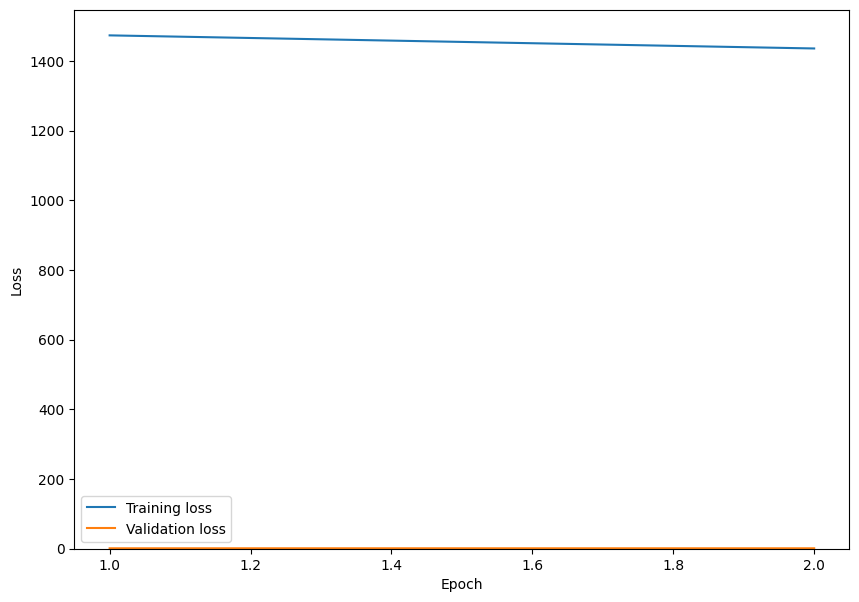

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.plot(range(1,len(hist_loss)+1),     hist_loss,     label="Training loss")
plt.plot(range(1,len(hist_val_loss)+1), hist_val_loss, label="Validation loss")

plt.ylim(ymin=0)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Check network on random event:
```
<event>
  3.016570943E+01  4.510460277E+01 -1.552387738E+02  1.644489954E+02
 -5.944532656E+01  1.420361466E+02 -3.064427199E+02  3.429506588E+02
 -3.520454553E+01  5.968701995E+01 -2.189955679E+01  7.267386713E+01
 -7.860515623E+01 -7.434789122E-01 -9.197268046E+01  1.209888313E+02
<rwgt>
<weight id='LL'> 0.360386982E-02 </weight>
<weight id='LT'> 0.914721633E-03 </weight>
<weight id='TL'> 0.168988248E-02 </weight>
<weight id='TT'> 0.160581823E-01 </weight>
</rwgt>
</event>
```

In [23]:
test_tensor = torch.tensor([ 3.016570943E+01,  4.510460277E+01, -1.552387738E+02, 1.644489954E+02,
                            -5.944532656E+01,  1.420361466E+02, -3.064427199E+02, 3.429506588E+02,
                            -3.520454553E+01,  5.968701995E+01, -2.189955679E+01, 7.267386713E+01,
                            -7.860515623E+01, -7.434789122E-01, -9.197268046E+01, 1.209888313E+02])

res = model(test_tensor.unsqueeze(0).to(device))
print(f"res = {res.item()/ 1000:.2e}")

res = 1.55e-04


In [16]:
#test the trained model

# let's test it on cpu
model.to(torch.device("cpu"))

X_test_pt = X_test_pt.type(torch.float).to(torch.device("cpu"))
res = model(X_test_pt)

NameError: name 'X_test_pt' is not defined

In [ ]:
print('Test accuracy: ',binary_accuracy(res, torch.unsqueeze(Y_test_pt,1)).item())

In [ ]:
!jupyter kernelspec list